In [1]:
# imports

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import and check it

df = pd.read_csv('data/bbc_clean.csv', sep=',')
df.head()

,Unnamed: 0,text,labels
0,0,musician tackle u red tape musician group tack...,entertainment
1,1,u desire number one u three prestigious grammy...,entertainment
2,2,rocker doherty stage fight rock singer pete do...,entertainment
3,3,snicket top u box office chart film adaptation...,entertainment
4,4,ocean twelve raid box office ocean twelve crim...,entertainment


In [3]:
# Check out the labels

df.labels.value_counts()

labels
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [4]:
# Use label encoder to prep the labels for machine learning.

label_encoder = LabelEncoder()
label_encoder.fit(df.labels)
df.labels = label_encoder.transform(df.labels)



In [5]:
# Check it

df.head()

,Unnamed: 0,text,labels
0,0,musician tackle u red tape musician group tack...,1
1,1,u desire number one u three prestigious grammy...,1
2,2,rocker doherty stage fight rock singer pete do...,1
3,3,snicket top u box office chart film adaptation...,1
4,4,ocean twelve raid box office ocean twelve crim...,1


In [6]:
# Double check with value counts

df.labels.value_counts()

labels
3    511
0    510
2    417
4    401
1    386
Name: count, dtype: int64

Note the value and order of the label are irrelevant. It matters only that the machine has a numeric target.

In [7]:
# remove the labels from the dataframe for clustering
df_no_labels = df.drop('labels', axis=1)

In [8]:
# Check
df_no_labels.head()

,Unnamed: 0,text
0,0,musician tackle u red tape musician group tack...
1,1,u desire number one u three prestigious grammy...
2,2,rocker doherty stage fight rock singer pete do...
3,3,snicket top u box office chart film adaptation...
4,4,ocean twelve raid box office ocean twelve crim...


In [9]:
# Use a vectorizer to prep the dataframe for clustering. I'm going to use TF-IDF in this example. 
# I'm also going to limit the document frequency to help

tf_idf = TfidfVectorizer(max_df=.95, min_df=.05)
X_vec = tf_idf.fit_transform(df_no_labels.text)
X_vec = pd.DataFrame.sparse.from_spmatrix(X_vec, columns=tf_idf.get_feature_names_out())
X_vec.head()

,able,accept,access,accord,account,accuse,across,act,action,actor,...,worry,would,write,wrong,xa,xc,year,yet,york,young
0,0,0,0,0,0,0,0.085999,0.257618,0,0,...,0,0.041884,0,0,0.056266,0.056304,0.035877,0,0,0
1,0,0,0,0.047297,0,0,0.055867,0,0,0,...,0,0,0,0,0,0,0.069919,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.05519,0.055228,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0.130694,...,0,0,0,0,0.147674,0.147776,0,0,0,0
4,0,0,0,0.07982,0,0,0.094283,0,0,0,...,0,0,0,0,0.308429,0.308642,0,0,0.10541,0


In [10]:
# Loop through 2-10 clusters, capturing inertia and Silhouette

sil_score = []
in_score = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=13)
    kmeans.fit(X_vec)
    sil_score.append(silhouette_score(X_vec, kmeans.labels_))
    in_score.append(kmeans.inertia_)

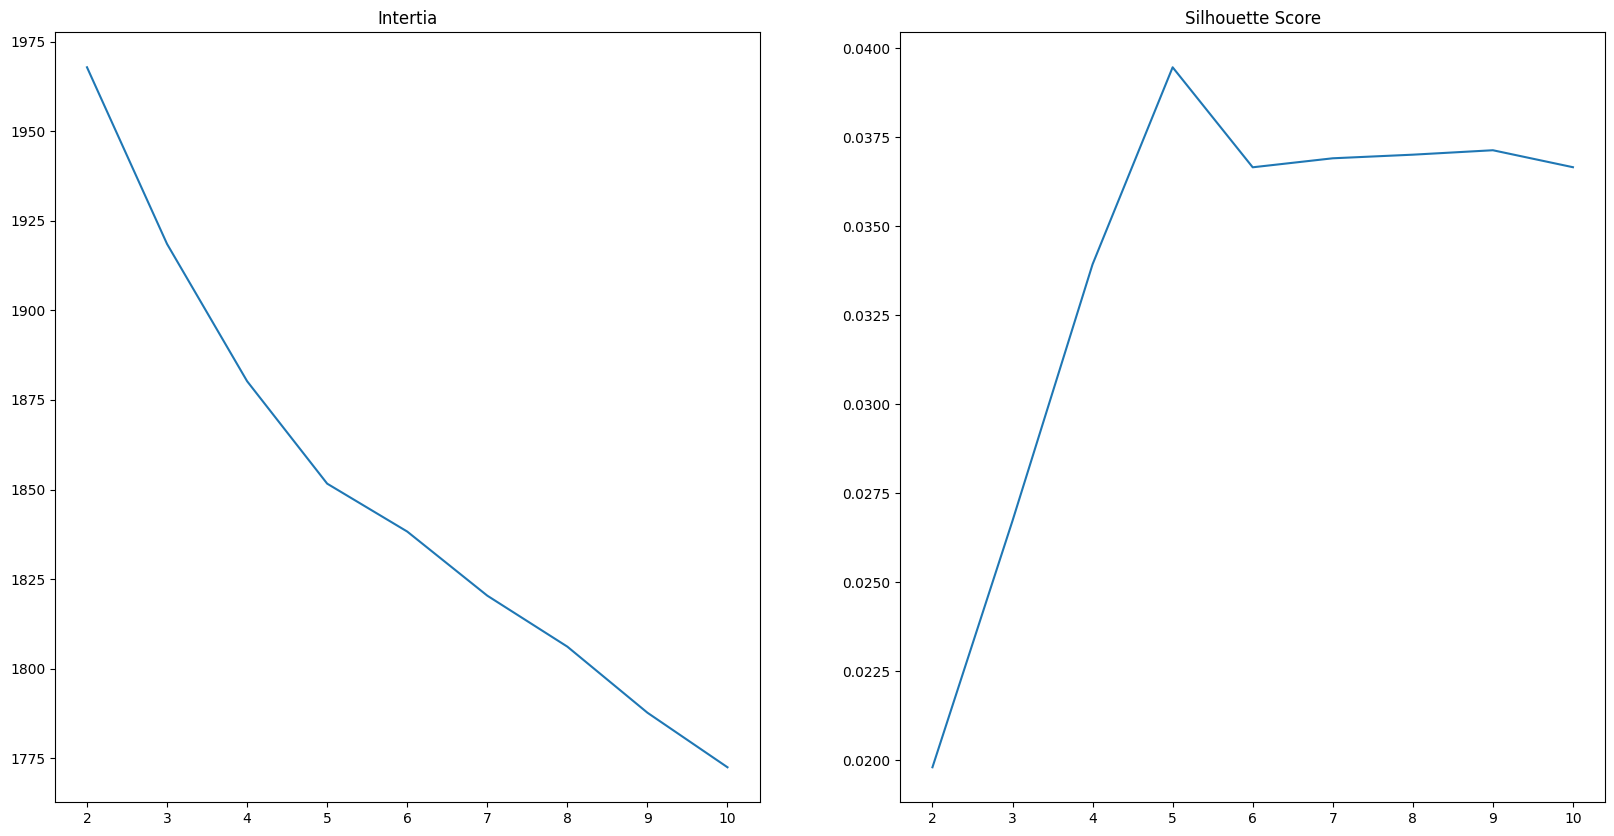

In [11]:
# Graph it!
fix, (ax1, ax2) = plt.subplots(1,2,figsize=(20,10))
ax1.ticklabel_format(style='plain')
ax1.plot(range(2,11),in_score)
ax2.plot(range(2,11),sil_score)
ax1.set_title( 'Intertia')
ax2.set_title('Silhouette Score');


When we look at the Inertia chart, keeping in mind the "elbow" method, it looks like five is a good candidate. 

Looking at the silhouette score, we can see that five has the highest, so we'll use that.

In [12]:
# We are going to instantiate a kmeans model using five clusters. Once we have that, add
# the cluster to the dataframe, as well as the labels.

kmeans = KMeans(n_clusters=5, random_state=13)
kmeans.fit(X_vec)
X_vec['cluster'] = kmeans.labels_
X_vec.head()


,able,accept,access,accord,account,accuse,across,act,action,actor,...,would,write,wrong,xa,xc,year,yet,york,young,cluster
0,0,0,0,0,0,0,0.085999,0.257618,0,0,...,0.041884,0,0,0.056266,0.056304,0.035877,0,0,0,1
1,0,0,0,0.047297,0,0,0.055867,0,0,0,...,0,0,0,0,0,0.069919,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0.05519,0.055228,0,0,0,0,3
3,0,0,0,0,0,0,0,0,0,0.130694,...,0,0,0,0.147674,0.147776,0,0,0,0,2
4,0,0,0,0.07982,0,0,0.094283,0,0,0,...,0,0,0,0.308429,0.308642,0,0,0.10541,0,2


In [13]:
# Prep the data for supervised learning.

X = X_vec
y = df.labels


In [14]:
# TTS!

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=13)

In [15]:
# Instantiate and fit

lr  = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [16]:
# Score!
print(f'The accuracy of train is {lr.score(X_train, y_train)}')
print(f'The accuracy of test is {lr.score(X_test, y_test)}')

The accuracy of train is 0.9634831460674157
The accuracy of test is 0.946067415730337


In [17]:
# Let us compare that result to a model without using the clustering labels
X_train_2 = X_train.drop('cluster', axis=1)
X_test_2 = X_test.drop('cluster', axis =1)

In [18]:
# Create a new logistic regression model
lr2 = LogisticRegression()
lr2.fit(X_train_2, y_train)

LogisticRegression()

In [19]:
# Score!
print(f'The accuracy of train is {lr2.score(X_train_2, y_train)}')
print(f'The accuracy of test is {lr2.score(X_test_2, y_test)}')

The accuracy of train is 0.9870786516853932
The accuracy of test is 0.9640449438202248
